# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Baseline Models

Today we work on the simplest models to act as a starting point that we will beat.

In [1]:
# imports

import os
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
from items import Item
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter

In [2]:
# More imports for our traditional machine learning

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## NLP imports

In the next cell, we have more imports for our NLP related machine learning.  
If the gensim import gives you an error like "Cannot import name 'triu' from 'scipy.linalg' then please run in another cell:  
`!pip install "scipy<1.13"`  
As described on StackOverflow [here](https://stackoverflow.com/questions/78279136/importerror-cannot-import-name-triu-from-scipy-linalg-when-importing-gens).  
Many thanks to students Arnaldo G and Ard V for sorting this.

In [3]:
# NLP related imports

from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [4]:
# Finally, more imports for more advanced machine learning

from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Constants - used for printing to stdout in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [6]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [7]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [8]:
%matplotlib inline

# Loading the pkl files

Let's avoid curating all our data again! Load in the pickle files

If you didn't already create these in Day 2, you can also download them from my google drive (you'll also find the slides here):  
https://drive.google.com/drive/folders/1JwNorpRHdnf_pU0GE5yYtfKlyrKC3CoV?usp=sharing

But note that the files are quite large - you might need to get a coffee!

In [9]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [10]:
# Remind ourselves the training prompt

print(train[0].prompt)

How much does this cost to the nearest dollar?

Solos for Young Violinists, Violin Part and Piano Accompaniment, Volume 4 by Barbara Barber
Solos for Young Violinists, Violin Part and Piano Accompaniment, Volume 4 by Barbara Barber is part of a graded series that contains works ranging from elementary to advanced levels and represented an exciting variety of styles and techniques for violinists, a valuable listening resource for teachers and students of all ages. This series can be used by any violinist and is supplementary to any method or course of study. Many of the pieces in this collection have long been recognized as stepping stones to the major violin repertoire, while others are newly published works. Solos for Young Violinists, Violin Part and Piano Accompaniment, Volume 4 by Barbara Barber is part of

Price is $14.00


In [11]:
# Remind a test prompt

print(train[0].price)

13.99


In [16]:
# Remind a test prompt

print(test[0].test_prompt())

How much does this cost to the nearest dollar?

Focusound 24 Packs Acoustic Foam Panels 2 X 12 X 12, Soundproofing Foam Noise Cancelling Foam with 120 PCS Double-Side adhesive
- Without Damaging Your Wall Our acoustic foam panles are equipped with 120 PCS double side adhesive tape which can be easily washed. It is easily removable and will not damage your walls or surfaces, tear off without leaving any traces. - Noise Reduction Overall Noise Reduction Coefficient (NRC) 0.65. The wedge surface of -6 grooves increases the contact area with sound waves, and the sound absorption effect is better than other shapes of surfaces. Will help reduce sounds and allow you to practice any musical instrument, watch movies, play games or listen to music without disturbing anyone. - High-Quality 25

Price is $


## Unveiling a mighty script that we will use a lot!

A rather pleasing Test Harness that will evaluate any model against 250 items from the Test set

And show us the results in a visually satisfying way.

You write a function of this form:

```
def my_prediction_function(item):
    # my code here
    return my_estimate
```

And then you call:

`Tester.test(my_prediction_function)`

To evaluate your model.

In [17]:
class Tester:

    def __init__(self, predictor, title=None, data=test, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"
    
    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint)
        truth = datapoint.price
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint.title if len(datapoint.title) <= 40 else datapoint.title[:40]+"..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function):
        cls(function).run()

# Now for something basic

What's the very simplest model you could imagine?

Let's start with a random number generator!

In [18]:
def random_pricer(item):
    return random.randrange(1,1000)

1: Guess: $655.00 Truth: $37.99 Error: $617.01 SLE: 7.97 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $115.00 Truth: $68.07 Error: $46.93 SLE: 0.27 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $26.00 Truth: $140.00 Error: $114.00 SLE: 2.73 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $760.00 Truth: $59.99 Error: $700.01 SLE: 6.37 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $282.00 Truth: $13.45 Error: $268.55 SLE: 8.85 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $251.00 Truth: $19.98 Error: $231.02 SLE: 6.18 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $229.00 Truth: $76.11 Error: $152.89 SLE: 1.19 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $143.00 Truth: $7.95 Error: $135.05 SLE: 7.72 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $755.00 Truth: $23.99 Error: $731.01 SLE: 11.63 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $105.00 Truth: $77.95 Error: $27.05 SLE:

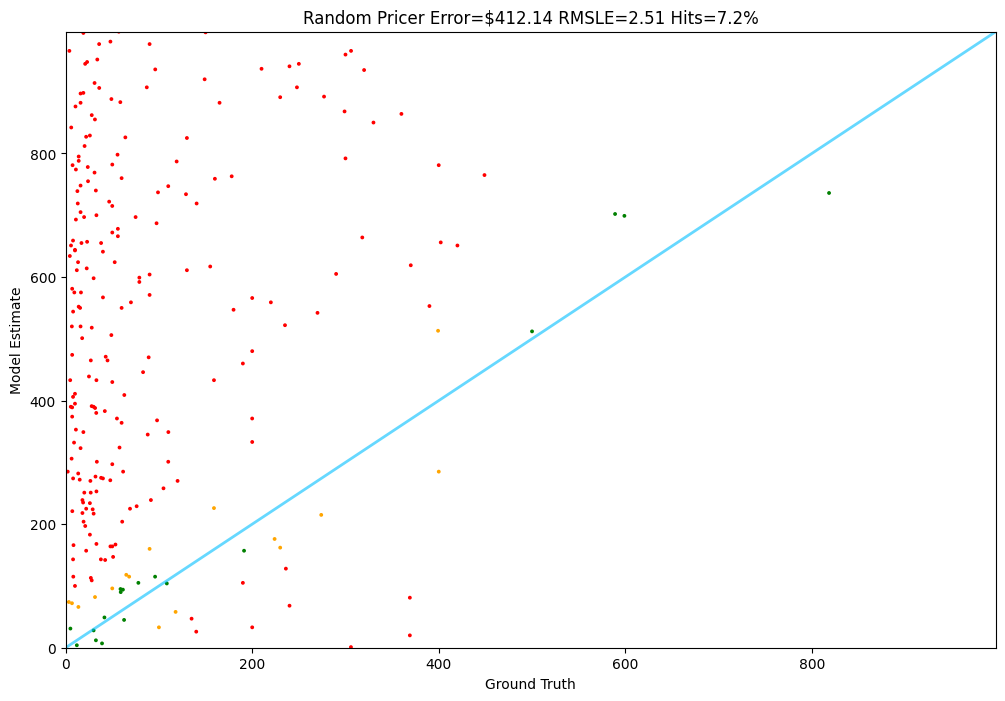

In [19]:
# Set the random seed

random.seed(42)

# Run our TestRunner
Tester.test(random_pricer)

In [20]:
# That was fun!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)

def constant_pricer(item):
    return training_average

1: Guess: $106.55 Truth: $37.99 Error: $68.56 SLE: 1.03 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $106.55 Truth: $68.07 Error: $38.48 SLE: 0.20 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $106.55 Truth: $140.00 Error: $33.45 SLE: 0.07 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $106.55 Truth: $59.99 Error: $46.56 SLE: 0.32 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $106.55 Truth: $13.45 Error: $93.10 SLE: 4.03 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $106.55 Truth: $19.98 Error: $86.57 SLE: 2.67 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $106.55 Truth: $76.11 Error: $30.44 SLE: 0.11 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $106.55 Truth: $7.95 Error: $98.60 SLE: 6.18 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $106.55 Truth: $23.99 Error: $82.56 SLE: 2.13 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $106.55 Truth: $77.95 Error: $28.60 SLE: 0.10 It

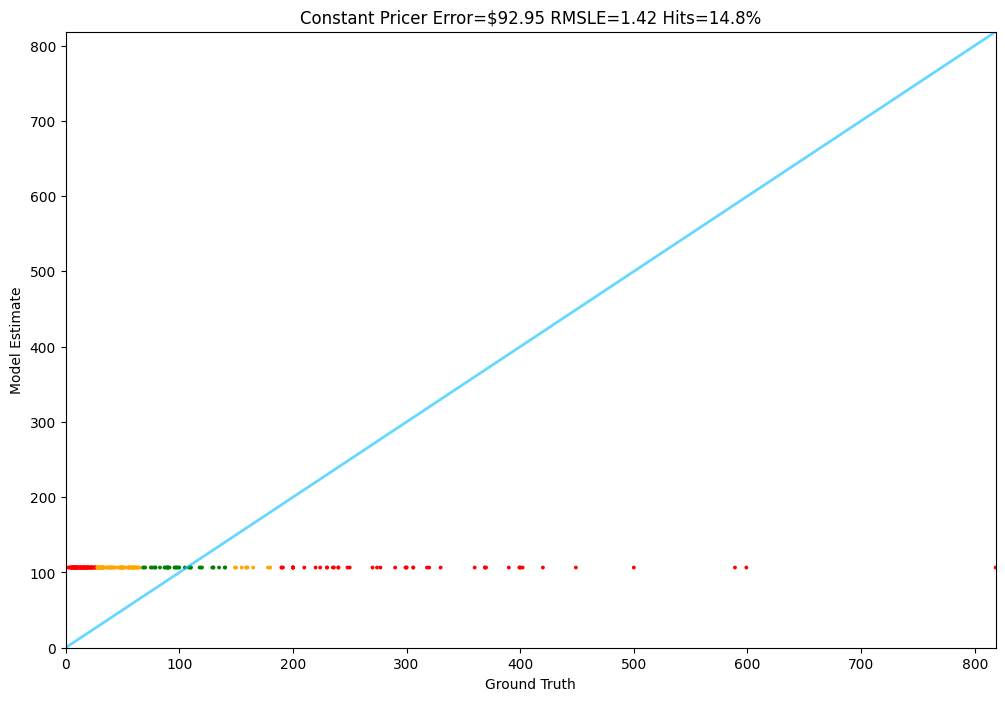

In [21]:
# Run our constant predictor
Tester.test(constant_pricer)


In [22]:
train[0].details

'{"Item Weight": "0.63 Pounds", "Package Dimensions": "11.7 x 8.8 x 0.3 inches", "Best Sellers Rank": {"Musical Instruments": 88876, "Musical Instrument Accessories": 43733}, "Is Discontinued By Manufacturer": "No", "Date First Available": "March 29, 2011", "Number of Strings": "4", "Brand": "Summy-Birchard", "Instrument": "Violin"}'

In [23]:
# Create a new "features" field on items, and populate it with json parsed from the details dict

for item in train:
    item.features = json.loads(item.details)
for item in test:
    item.features = json.loads(item.details)

# Look at one

In [25]:
print(train[0].features)

{'Item Weight': '0.63 Pounds', 'Package Dimensions': '11.7 x 8.8 x 0.3 inches', 'Best Sellers Rank': {'Musical Instruments': 88876, 'Musical Instrument Accessories': 43733}, 'Is Discontinued By Manufacturer': 'No', 'Date First Available': 'March 29, 2011', 'Number of Strings': '4', 'Brand': 'Summy-Birchard', 'Instrument': 'Violin'}


In [24]:
train[0].features.keys()

dict_keys(['Item Weight', 'Package Dimensions', 'Best Sellers Rank', 'Is Discontinued By Manufacturer', 'Date First Available', 'Number of Strings', 'Brand', 'Instrument'])

In [26]:
# Look at 20 most common features in training set

feature_count = Counter()
for item in train:
    for f in item.features.keys():
        feature_count[f]+=1

feature_count.most_common(40)

[('Date First Available', 69814),
 ('Item Weight', 62688),
 ('Best Sellers Rank', 61077),
 ('Item model number', 54515),
 ('Brand', 48951),
 ('Product Dimensions', 43200),
 ('Is Discontinued By Manufacturer', 34589),
 ('Color', 33367),
 ('Color Name', 28039),
 ('Manufacturer', 22815),
 ('Material', 20495),
 ('Package Dimensions', 20227),
 ('Material Type', 19874),
 ('Country of Origin', 18049),
 ('Part Number', 15950),
 ('Size', 15326),
 ('Item Dimensions LxWxH', 14849),
 ('Batteries Required?', 14065),
 ('Batteries Included?', 11455),
 ('Style', 11130),
 ('Included Components', 11112),
 ('Power Source', 10391),
 ('Compatible Devices', 9545),
 ('Special Feature', 9283),
 ('Connector Type', 7663),
 ('Body Material', 7586),
 ('Number of Strings', 7381),
 ('Model Name', 6980),
 ('Brand Name', 6226),
 ('Connectivity Technology', 6123),
 ('Item Package Quantity', 5927),
 ('Voltage', 5703),
 ('Finish Type', 5393),
 ('Back Material', 4821),
 ('Domestic Shipping', 4775),
 ('International Shipp

In [27]:
# Now some janky code to pluck out the Item Weight
# Don't worry too much about this: spoiler alert, it's not going to be much use in training!

def get_weight(item):
    weight_str = item.features.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [28]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]

In [29]:
average_weight = sum(weights)/len(weights)
average_weight

4.433769868318432

In [30]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [31]:
def get_rank(item):
    rank_dict = item.features.get("Best Sellers Rank")
    if rank_dict:
        ranks = rank_dict.values()
        return sum(ranks)/len(ranks)
    return None

In [32]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

96884.74720929087

In [33]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [34]:
def get_text_length(item):
    return len(item.test_prompt())

In [35]:
# investigate the brands

brands = Counter()
for t in train:
    brand = t.features.get("Brand")
    if brand:
        brands[brand]+=1

# Look at most common 40 brands

brands.most_common(40)

[('Fender', 526),
 ('Whirlpool', 442),
 ('GE', 440),
 ('Frigidaire', 424),
 ('Upstart Battery', 387),
 ('Rockville', 341),
 ('JIM DUNLOP', 339),
 ('Pyle', 331),
 ('Latin Percussion', 328),
 ('WORLDS BEST CABLES', 273),
 ('Ibanez', 257),
 ('Yamaha', 255),
 ('Hohner Accordions', 251),
 ('Seismic Audio', 246),
 ('Supplying Demand', 246),
 ('Behringer', 241),
 ('OnStage', 231),
 ('Musiclily', 228),
 ('Audio-Technica', 227),
 ("D'Addario", 188),
 ('Shure', 181),
 ('GIBRALTAR', 175),
 ('Generic', 174),
 ('Meinl Percussion', 171),
 ('Remo', 169),
 ('SAMSUNG', 168),
 ('Stagg', 164),
 ('Kala', 163),
 ('Sabian', 160),
 ('Roland', 153),
 ('Seymour Duncan', 152),
 ('UpStart Components', 152),
 ('SKB', 149),
 ('DR Strings', 147),
 ('JOYO', 146),
 ('Samson', 145),
 ('Peavey', 132),
 ('Audio 2000S', 131),
 ('ICEPURE', 129),
 ('Gator', 127)]

In [36]:
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]
def is_top_electronics_brand(item):
    brand = item.features.get("Brand")
    return brand and brand.lower() in TOP_ELECTRONICS_BRANDS

In [37]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0
    }

In [38]:
# Look at features in a training item
get_features(train[0])

{'weight': 0.63,
 'rank': 66304.5,
 'text_length': 833,
 'is_top_electronics_brand': 0}

In [39]:
# A utility function to convert our features into a pandas dataframe

def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:250])

In [40]:
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'rank', 'text_length', 'is_top_electronics_brand']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 5.748322795153176
rank: -6.711772112365454e-05
text_length: 0.07983250144998556
is_top_electronics_brand: 3.553529888608606
Intercept: 25.969773120835782
Mean Squared Error: 9768.889171875968
R-squared Score: 0.3543307714661149


In [41]:
# Function to predict price for a new item

def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $114.77 Truth: $37.99 Error: $76.78 SLE: 1.18 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $121.28 Truth: $68.07 Error: $53.21 SLE: 0.33 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $100.99 Truth: $140.00 Error: $39.01 SLE: 0.10 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $114.93 Truth: $59.99 Error: $54.94 SLE: 0.41 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $88.11 Truth: $13.45 Error: $74.66 SLE: 3.31 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $90.22 Truth: $19.98 Error: $70.24 SLE: 2.16 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $83.70 Truth: $76.11 Error: $7.59 SLE: 0.01 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $87.26 Truth: $7.95 Error: $79.31 SLE: 5.24 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $68.70 Truth: $23.99 Error: $44.71 SLE: 1.05 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $75.06 Truth: $77.95 Error: $2.89 SLE: 0.00 Item: Ange

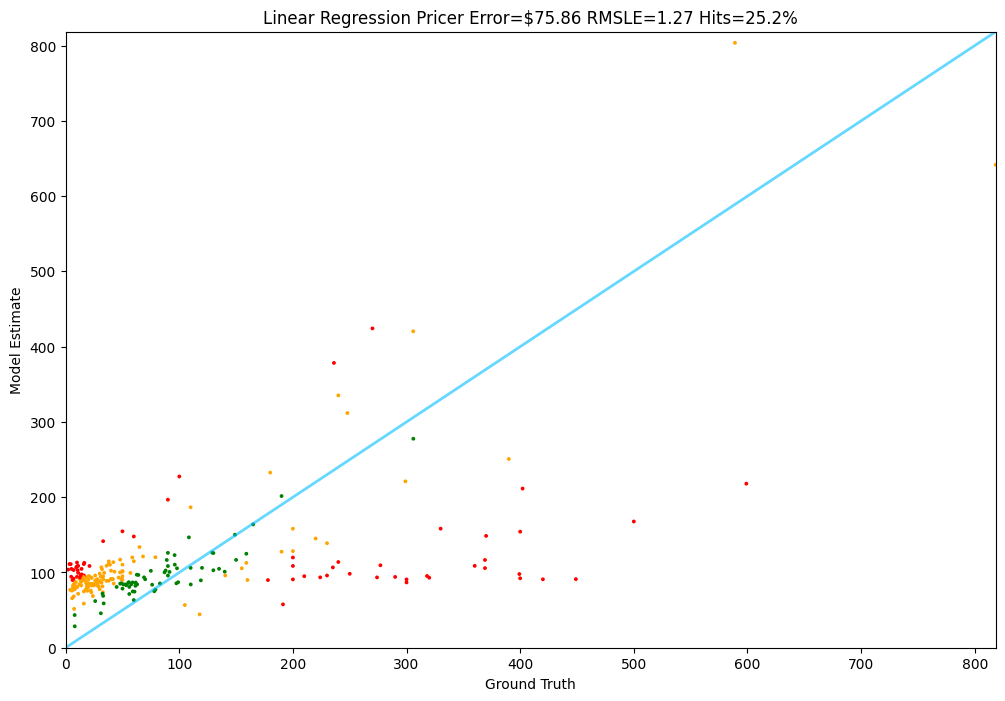

In [42]:
# test it

Tester.test(linear_regression_pricer)

In [44]:
# For the next few models, we prepare our documents and prices
# Note that we use the test prompt for the documents, otherwise we'll reveal the answer!!

prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [45]:
# Use the CountVectorizer for a Bag of Words model

np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices)

LinearRegression()

In [46]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

1: Guess: $92.59 Truth: $37.99 Error: $54.60 SLE: 0.77 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $148.12 Truth: $68.07 Error: $80.05 SLE: 0.59 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $207.29 Truth: $140.00 Error: $67.29 SLE: 0.15 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $52.48 Truth: $59.99 Error: $7.51 SLE: 0.02 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $0.00 Truth: $13.45 Error: $13.45 SLE: 7.13 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $108.25 Truth: $19.98 Error: $88.27 SLE: 2.72 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $0.00 Truth: $76.11 Error: $76.11 SLE: 18.88 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $61.45 Truth: $7.95 Error: $53.50 SLE: 3.77 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $134.58 Truth: $23.99 Error: $110.59 SLE: 2.86 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $130.55 Truth: $77.95 Error: $52.60 SLE: 0.26 Item: An

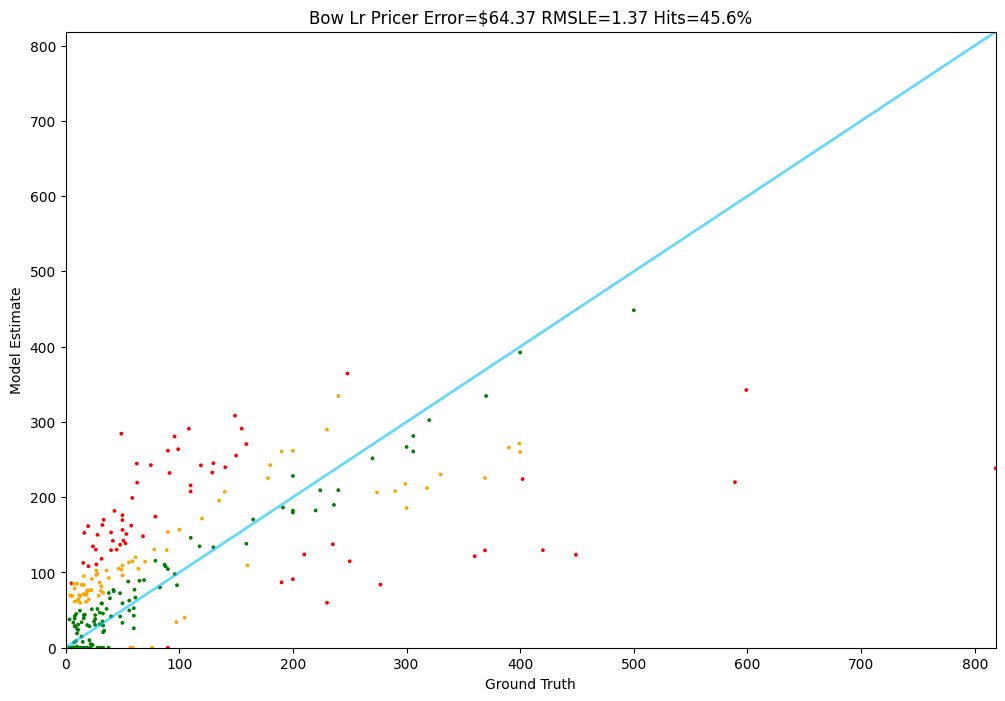

In [47]:
# test it

Tester.test(bow_lr_pricer)

In [48]:
# The amazing word2vec model, implemented in gensim NLP library

np.random.seed(42)

# Preprocess the documents
processed_docs = [simple_preprocess(doc) for doc in documents]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

In [49]:
# This step of averaging vectors across the document is a weakness in our approach

def document_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size)

# Create feature matrix
X_w2v = np.array([document_vector(doc) for doc in documents])

In [50]:
# Run Linear Regression on word2vec

word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

LinearRegression()

In [51]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

1: Guess: $47.89 Truth: $37.99 Error: $9.90 SLE: 0.05 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $209.13 Truth: $68.07 Error: $141.06 SLE: 1.24 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $160.86 Truth: $140.00 Error: $20.86 SLE: 0.02 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $45.73 Truth: $59.99 Error: $14.26 SLE: 0.07 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $0.00 Truth: $13.45 Error: $13.45 SLE: 7.13 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $137.80 Truth: $19.98 Error: $117.82 SLE: 3.57 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $56.30 Truth: $76.11 Error: $19.81 SLE: 0.09 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $58.14 Truth: $7.95 Error: $50.19 SLE: 3.57 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $185.73 Truth: $23.99 Error: $161.74 SLE: 4.04 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $101.57 Truth: $77.95 Error: $23.62 SLE: 0.07 Item: 

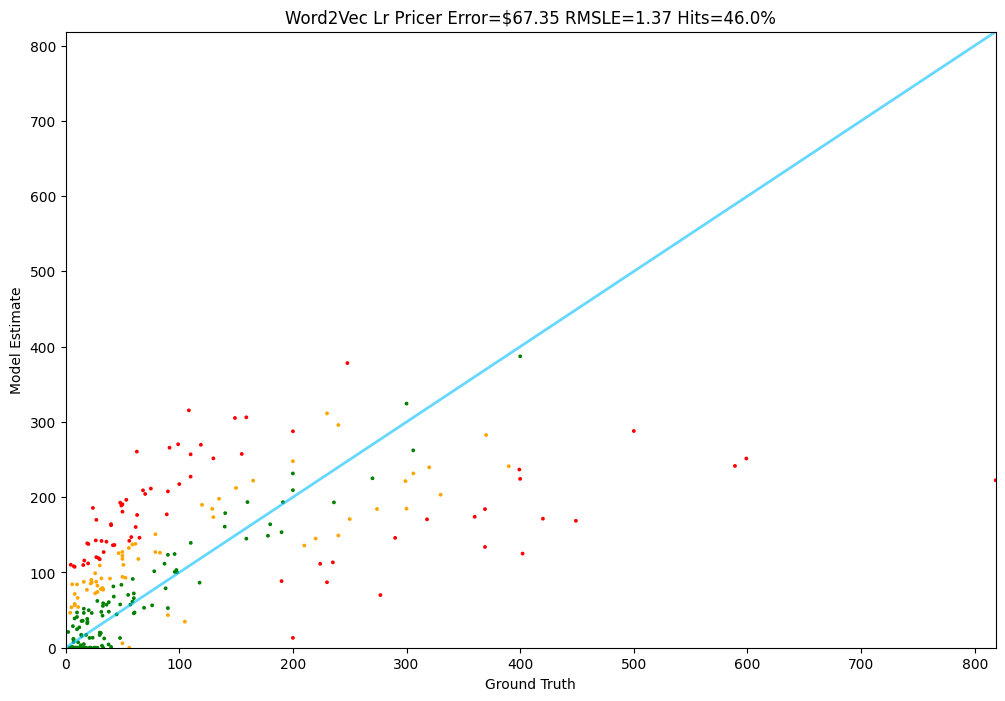

In [52]:
Tester.test(word2vec_lr_pricer)

In [53]:
# Support Vector Machines

np.random.seed(42)
svr_regressor = LinearSVR()

svr_regressor.fit(X_w2v, prices)

LinearSVR()

In [54]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

1: Guess: $26.65 Truth: $37.99 Error: $11.34 SLE: 0.12 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $131.44 Truth: $68.07 Error: $63.37 SLE: 0.42 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $90.73 Truth: $140.00 Error: $49.27 SLE: 0.18 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $37.92 Truth: $59.99 Error: $22.07 SLE: 0.20 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $0.00 Truth: $13.45 Error: $13.45 SLE: 7.13 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $70.64 Truth: $19.98 Error: $50.66 SLE: 1.51 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $55.09 Truth: $76.11 Error: $21.02 SLE: 0.10 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $45.47 Truth: $7.95 Error: $37.52 SLE: 2.71 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $120.74 Truth: $23.99 Error: $96.75 SLE: 2.51 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $58.91 Truth: $77.95 Error: $19.04 SLE: 0.08 Item: Angel

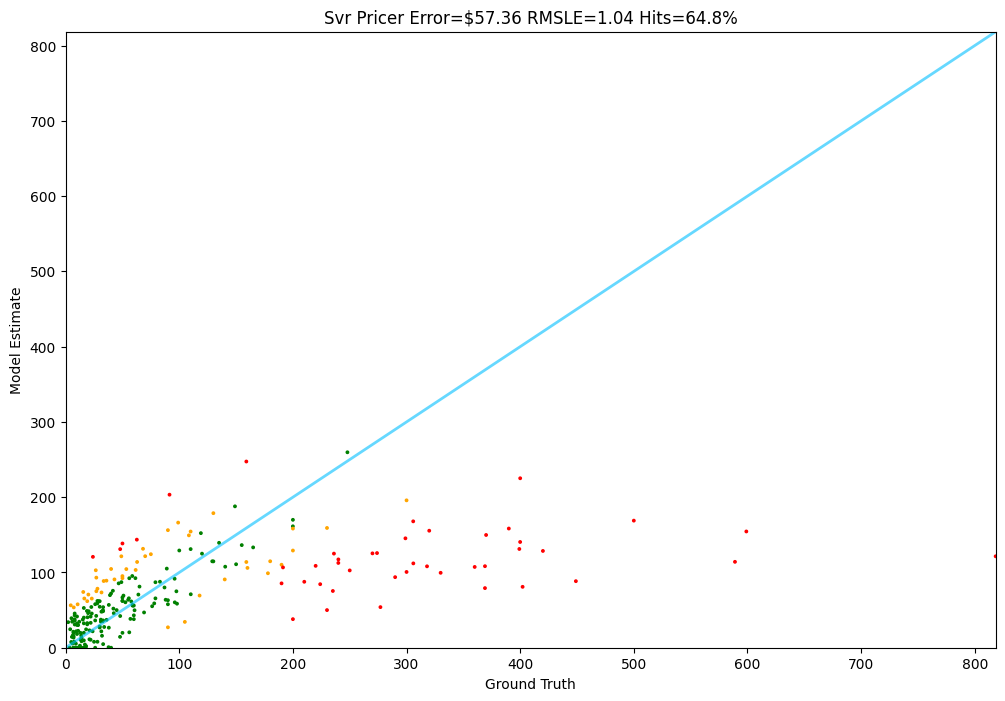

In [55]:
Tester.test(svr_pricer)

In [56]:
# And the powerful Random Forest regression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=8)
rf_model.fit(X_w2v, prices)

RandomForestRegressor(n_jobs=8, random_state=42)

In [57]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

1: Guess: $47.21 Truth: $37.99 Error: $9.22 SLE: 0.05 Item: Focusound 24 Packs Acoustic Foam Panels ...
2: Guess: $192.28 Truth: $68.07 Error: $124.21 SLE: 1.06 Item: Samson SP100 Speaker Stand (Single Stand...
3: Guess: $86.77 Truth: $140.00 Error: $53.23 SLE: 0.22 Item: Wireless Microphone for Smartphone, Comi...
4: Guess: $54.84 Truth: $59.99 Error: $5.15 SLE: 0.01 Item: Yovus Pro Audio Recessed Stage Floor Poc...
5: Guess: $13.84 Truth: $13.45 Error: $0.39 SLE: 0.00 Item: ROSENICE DIY Guitar Pick Punch Sheets Mu...
6: Guess: $45.05 Truth: $19.98 Error: $25.07 SLE: 0.62 Item: Otamatone Melody - Fun Japanese Electron...
7: Guess: $57.64 Truth: $76.11 Error: $18.47 SLE: 0.07 Item: BOSS Guitar Strap (BSL-30-BLK)
8: Guess: $31.83 Truth: $7.95 Error: $23.88 SLE: 1.69 Item: Movo SMVXR10 Replacement Shockmount for ...
9: Guess: $68.82 Truth: $23.99 Error: $44.83 SLE: 1.06 Item: LUKYER 634166 Door Hinge Kit，Replacement...
10: Guess: $98.99 Truth: $77.95 Error: $21.04 SLE: 0.06 Item: Angel 4

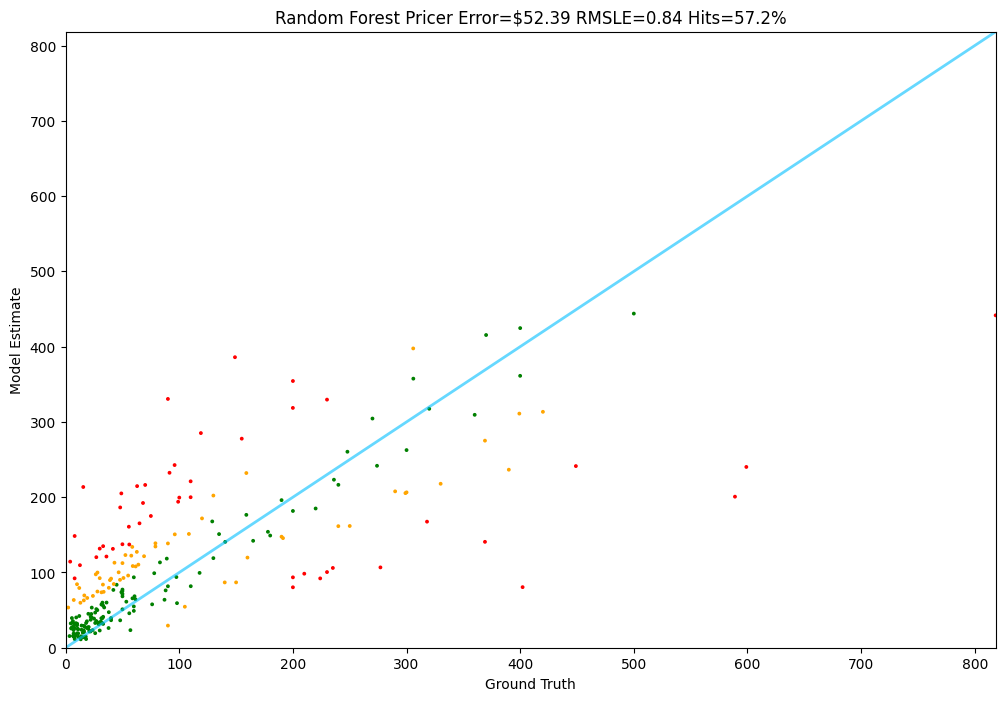

In [58]:
Tester.test(random_forest_pricer)